In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
!export OMP_NUM_THREADS=1
!export MKL_NUM_THREADS=1
!export OPENBLAS_NUM_THREADS=1

In [9]:
pip install pyqmd

  Using cached pyqmd-0.1.0-py3-none-any.whl.metadata (801 bytes)
  Using cached lancedb-0.30.2-cp39-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached nano_graphrag-0.0.8.2-py3-none-any.whl.metadata (15 kB)
  Using cached pyarrow-24.0.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached pydantic-2.13.3-py3-none-any.whl.metadata (108 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached tomli_w-1.2.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached deprecation-2.1.0-py2.py3-none-any.whl.metadata (4.6 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached lance_namespace-0.7.0-py3-n

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [91 lines of output]
      C:\Users\masah\AppData\Local\Temp\pip-build-env-ir_7hk8e\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\masah\AppData\Local\Temp\pip-build-env-ir_7hk8e\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\masah\AppData\Local\Temp\pip-build-env-ir_7hk8e\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Appr

In [3]:
pip install opt_einsum

  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install gensim --only-binary :all:

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ------ --------------------------------- 3.9/24.4 MB 21.5 MB/s eta 0:00:01
   ----------------- ---------------------- 10.7/24.4 MB 27.9 MB/s eta 0:00:01
   --------------------------- ------------ 16.5/24.4 MB 29.6 MB/s eta 0:00:01
   -------------------------------- ------- 19.7/24.4 MB 24.5 MB/s eta 0:00:01
   -------------------------------------- - 23.6/24.4 MB 23.1 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 22.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import itertools
import numpy as np
from opt_einsum import contract
from matplotlib import pyplot as plt

from pyqmd.tdmcscf.nuc1d_mctdhf import alpha1d_tdhf, alpha1d_mctdhf
from pyqmd.tdmcscf.nuc1d_mctdhf_old import alpha1d_tdhf_old, alpha1d_mctdhf_old
from pyqmd.misc_utils.propagator import propagator_rk4

ModuleNotFoundError: No module named 'pyqmd'

In [5]:
fedvr_parameters = {
    'n_DVR': 2,
    #'FEM': [-100 + 0.1*i for i in range(2001)],
    'FEM': [-100 + 0.2*i for i in range(1001)],                                                                                                     
    #'FEM': [-100 + 0.4*i for i in range(501)],                                                                                                      
    'R_ecs': 0,
    'theta_ecs': 0,
    }

fedvr_parameters_ecs = {
    'n_DVR': 2,
    #'FEM': [-100 + 0.1*i for i in range(2001)],
    'FEM': [-100 + 0.2*i for i in range(1001)],                                                                                                     
    #'FEM': [-100 + 0.4*i for i in range(501)],                                                                                                      
    'R_ecs': 75,
    'theta_ecs': 30,
    }

### DEBUG for low-rank approximation

In [6]:
tdhf = alpha1d_tdhf(
    n_alpha=1,
    fedvr_parameters=fedvr_parameters, 
)

xpt = tdhf.basis.xpt
u_init = tdhf.initial_guess()
rho = tdhf.basis.calc_1body_density(tdhf.u2wfn(u_init))

NameError: name 'alpha1d_tdhf' is not defined

In [6]:
tdhf_lowrank = alpha1d_tdhf(
    n_alpha=1,
    fedvr_parameters=fedvr_parameters, 
    coulomb_parameters={"interaction_type":2}
)

In [7]:
tdhf_sep_lowrank = {}
for R_matching in (1, 2, 5, 10, 20): 
    tdhf_sep_lowrank[R_matching] = {}
    for poly_order in (0,1,2,3,4,):
        tdhf_sep_lowrank[R_matching][poly_order] = alpha1d_tdhf(
            n_alpha=1,
            fedvr_parameters=fedvr_parameters, 
            coulomb_parameters={"interaction_type":3, 
                                "x_match": R_matching, 
                                "n_max": poly_order
                               }
        )

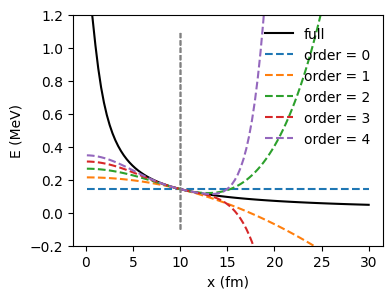

In [8]:
x_max = 30
x_array = np.linspace(0.1, x_max, 100)
f_orig = tdhf.pot_coulomb.func12.evaluate_func(x_array)

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(x_array, f_orig, color="black", label="full")

R_matching = 10
for m in (0,1,2,3,4,):

    even_poly_array = tdhf_sep_lowrank[R_matching][m].basis.C2_potential.func12.evaluate_polynomial(x_array)
    ax.plot(x_array, even_poly_array, label=f"order = {m}", ls='dashed')    
    ax.plot([R_matching,]*2, [-0.1,1.1], color="gray", lw=1, ls="dashed")
    
ax.set_xlabel("x (fm)")
ax.set_ylabel("E (MeV)")

#ax.set_xlim([-0.2,8.2])
ax.set_ylim([-0.2,1.2])
ax.legend(frameon=False)
plt.show()


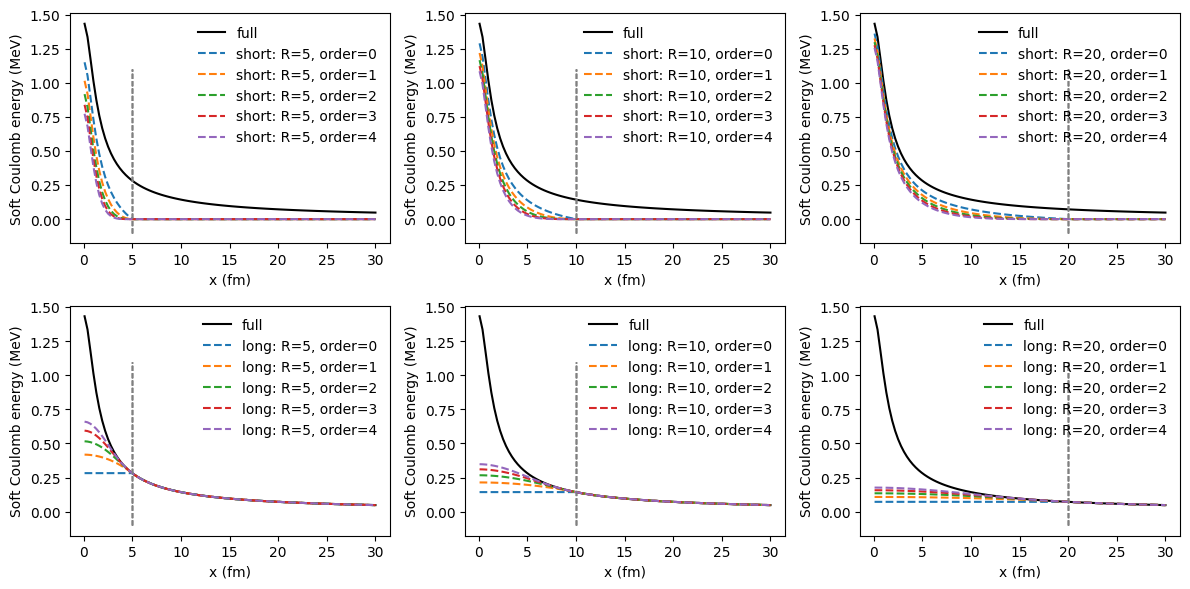

In [9]:
x_max = 30
x_array = np.linspace(0.1, x_max, 100)
f_orig = tdhf.pot_coulomb.func12.evaluate_func(x_array)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12,6))

for i_col, R_matching in enumerate((5,10,20)):

    ax[0,i_col].plot(x_array, f_orig, color="black", label="full")
    ax[1,i_col].plot(x_array, f_orig, color="black", label="full")
    
    for poly_order in (0,1,2,3,4,):
        solver = tdhf_sep_lowrank[R_matching][poly_order]

        f_short = solver.basis.C2_potential.func12.evaluate_func_short(x_array)
        f_long = solver.basis.C2_potential.func12.evaluate_func_long(x_array)

        ax[0,i_col].plot(x_array, f_short, 
                       label=f"short: R={R_matching}, order={poly_order}", ls="dashed")
        ax[1,i_col].plot(x_array, f_long, 
                       label=f"long: R={R_matching}, order={poly_order}", ls="dashed")

        ax[0,i_col].plot([R_matching,]*2, [-0.1,1.1], color="gray", lw=1, ls="dashed")
        ax[1,i_col].plot([R_matching,]*2, [-0.1,1.1], color="gray", lw=1, ls="dashed")

    ax[0,i_col].legend(frameon=False)
    ax[0,i_col].set_xlabel("x (fm)")
    ax[0,i_col].set_ylabel("Soft Coulomb energy (MeV)")
    ax[1,i_col].legend(frameon=False)
    ax[1,i_col].set_xlabel("x (fm)")
    ax[1,i_col].set_ylabel("Soft Coulomb energy (MeV)")
plt.tight_layout()
plt.show()


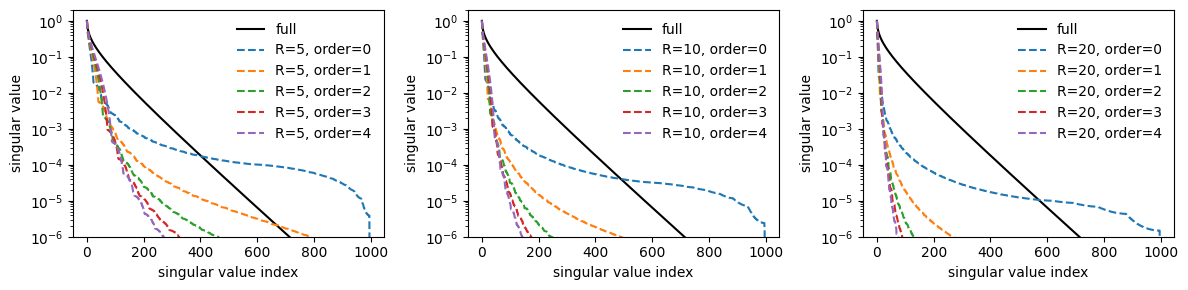

In [10]:
fig, ax = plt.subplots(ncols=3, figsize=(12,3))

for i_col, R_matching in enumerate((5,10,20)):

    Zsvd = tdhf_lowrank.pot_coulomb.Z_lr
    ax[i_col].plot(Zsvd/Zsvd[0], label="full", color="black")
    #ax[i_col].plot(Zsvd_sr_R[R_matching][0], label=f"short range {R_matching}", ls="dotted")
    for poly_order in (0,1,2,3,4,):
        Zsvd_lr_R = tdhf_sep_lowrank[R_matching][poly_order].pot_coulomb.Z_lr
        ax[i_col].plot(Zsvd_lr_R/Zsvd_lr_R[0], 
                       label=f"R={R_matching}, order={poly_order}", ls="dashed")

    ax[i_col].set_xlabel(f"singular value index")
    ax[i_col].set_ylabel("singular value")

    ax[i_col].set_yscale("log")
    #ax[i_col].set_xlim([-1,200])
    ax[i_col].set_ylim([1e-6,2])
    ax[i_col].legend(frameon=False)
plt.tight_layout()
plt.show()

In [11]:
from opt_einsum import contract

max_index_list = [10+5*j for j in range(39)] # 10,20,..,200

C2pot = tdhf.basis.calc_C2_potential(rho)
_Ene_full = contract("ikx,jlx->ijkl", rho, C2pot)[0,0,0,0].real

rel_error = []
smallest_sv = []

for max_index in max_index_list:
    C2pot = np.zeros_like(rho)
    tdhf_lowrank.basis.C2_potential.evaluate_potential(rho, C2pot, max_sv=max_index)
    _Ene = contract("ikx,jlx->ijkl", rho, C2pot)[0,0,0,0].real
    _rel_error = 100*(_Ene-_Ene_full)/abs(_Ene_full)
    rel_error.append(_rel_error)
    smallest_sv.append(tdhf_lowrank.basis.C2_potential.Z_lr[max_index])

rel_error_R = {}
smallest_sv_R = {}
for R_matching in (1,2,5,10,20):
    #print(f"##### Separation, matching at R = {R_matching} a.u #####")
    rel_error_R[R_matching] = {}
    smallest_sv_R[R_matching] = {}

    for poly_order in (0,1,2,3,4,):

        rel_error_R[R_matching][poly_order] = []
        smallest_sv_R[R_matching][poly_order] = []
    
        for max_index in max_index_list:
            C2pot = np.zeros_like(rho)
            tdhf_sep_lowrank[R_matching][poly_order].basis.C2_potential.evaluate_potential(rho, C2pot, max_sv=max_index)
            _Ene = contract("ikx,jlx->ijkl", rho, C2pot)[0,0,0,0].real
            _rel_error = 100*(_Ene-_Ene_full)/abs(_Ene_full)
            rel_error_R[R_matching][poly_order].append(_rel_error)
            smallest_sv_R[R_matching][poly_order].append(tdhf_sep_lowrank[R_matching][poly_order].basis.C2_potential.Z_lr[max_index])


$$
W(x_1) = \int dx_2 v(x_1,x_2) \rho(x_2) = \sum_\mu \xi_\mu(x_1) \int dx_2 \eta^*_\mu(x_2) \rho(x_2)
$$

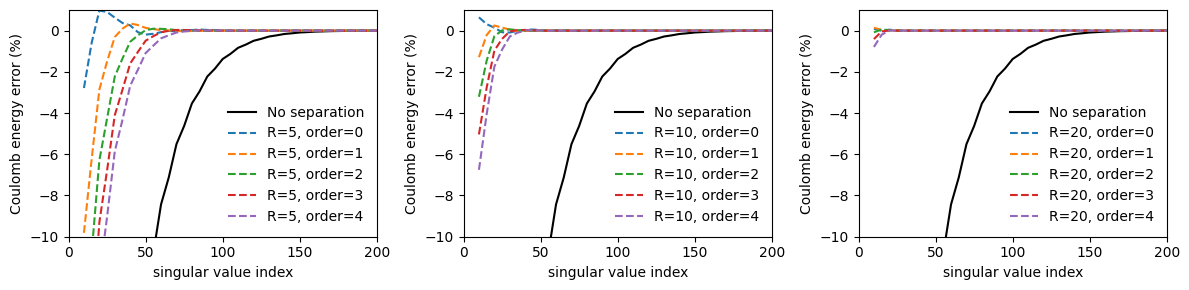

In [12]:
fig, ax = plt.subplots(ncols=3, figsize=(12,3))

for i_col,R_matching in enumerate((5,10,20)):

    ax[i_col].plot(max_index_list, rel_error, label="No separation", color="black")

    for poly_order in (0,1,2,3,4,):
        
        ax[i_col].plot(max_index_list, rel_error_R[R_matching][poly_order], ls="dashed", label=f"R={R_matching}, order={poly_order}")

    ax[i_col].set_xlabel("singular value index")
    ax[i_col].set_ylabel("Coulomb energy error (%)")
    ax[i_col].set_xlim([0,200])
    ax[i_col].set_ylim([-10,1])
    ax[i_col].legend(frameon=False)

plt.tight_layout()
plt.show()

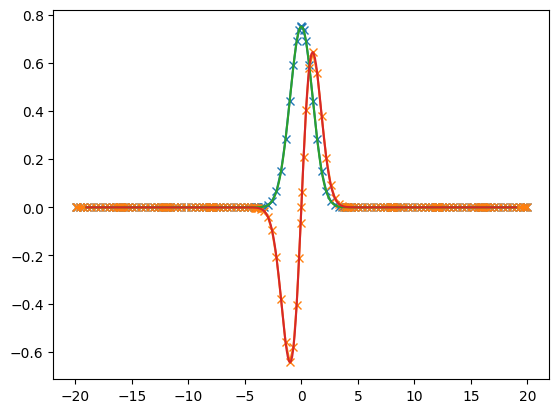

In [695]:
fedvr_parameters2 = {
    'n_DVR': 16,
    'FEM': [-20 + 4*i for i in range(11)],
    'R_ecs': 0,
    'theta_ecs': 0,
    }
test_mctdhf = alpha1d_mctdhf(n_alpha=1, n_fun=2, fedvr_parameters=fedvr_parameters2)
wfn_init = test_mctdhf.initial_guess(h_diagonalize=False)
orb_init, _ = test_mctdhf.get_orbcic(wfn_init)


fedvr = test_mctdhf.basis.basis.BasX
x_array = np.linspace(-19,19,381)
b_array = fedvr.evaluate_basis_functions_vector(x_array)
orb_array = (b_array @ orb_init.T).T

fig, ax = plt.subplots()
#ax.plot(fedvr_evaluator.x_array, f_array, marker='x')
ax.plot(fedvr.xpt, orb_init[0,:].real/np.sqrt(fedvr.wpt.real), marker='x')
ax.plot(fedvr.xpt, orb_init[1,:].real/np.sqrt(fedvr.wpt.real), marker='x')

ax.plot(x_array, orb_array[0,:])
ax.plot(x_array, orb_array[1,:])
plt.show()

In [696]:
rho1 = test_mctdhf.basis.calc_1body_density(orb_init)
Cpot = test_mctdhf.basis.calc_C2_potential(rho1)
int2 = contract("ikx,jlx->ijkl", rho1, Cpot)
print(int2)

[[[[ 1.02089244e+00+0.j  0.00000000e+00+0.j]
   [-1.66533454e-16+0.j  2.67318588e-01+0.j]]

  [[ 0.00000000e+00+0.j  8.99492670e-01+0.j]
   [ 2.67318588e-01+0.j  5.55111512e-17+0.j]]]


 [[[-1.66533454e-16+0.j  2.67318588e-01+0.j]
   [ 8.99492670e-01+0.j  0.00000000e+00+0.j]]

  [[ 2.67318588e-01+0.j  5.55111512e-17+0.j]
   [ 0.00000000e+00+0.j  8.95812244e-01+0.j]]]]


In [697]:
poly_order = 5
n_seeds = 1
for i_dvr, (i_order,i_seed) in enumerate(
    itertools.product(
        range(poly_order), range(n_seeds)
    )):
    #phi[:,i_dvr] = orb_seed[i_seed]*(xpt**i_order)
    print(i_dvr, i_order, i_seed)


0 0 0
1 1 0
2 2 0
3 3 0
4 4 0


In [698]:
def map_to_minus1_1(x_array):
    """
    Map x in [xmin, xmax] to y in [-1,1]
    """
    x_array = np.asarray(x_array, dtype=np.complex128)
    xmin = x_array.min()
    xmax = x_array.max()

    xc = 0.5 * (xmin + xmax)
    L = xmax - xmin

    y_array = 2.0 * (x_array - xc) / L
    return y_array, xc, L


def legendre_polynomials(y_array, M):
    """
    Compute Legendre polynomials P_0..P_M evaluated at y_array.

    Returns:
        P: shape (len(y_array), M+1)
        P[:, k] = P_k(y_array)
    """
    y = np.asarray(y_array, dtype=np.complex128)
    G = y.size

    P = np.zeros((G, M+1), dtype=np.complex128)

    # P0 = 1
    P[:, 0] = 1.0

    if M >= 1:
        # P1 = y
        P[:, 1] = y

    for k in range(1, M):
        # recurrence:
        # (k+1) P_{k+1} = (2k+1) y P_k - k P_{k-1}
        P[:, k+1] = ((2*k+1)*y*P[:, k] - k*P[:, k-1]) / (k+1)

    return P

class tddvr():
    def __init__(self, FEDVR):
        self.FEDVR = FEDVR
        self.xpt = self.FEDVR.xpt
        self.ypt, self.xc, self.L = map_to_minus1_1(self.xpt)
        self.n_bas = len(self.FEDVR.xpt)

    def generate_basis(self, orb_seed, poly_order=0, poly_type="y", small=1E-12):
        self.n_seeds = orb_seed.shape[0]
        self.poly_order = poly_order
        self.n_dvr0 = self.n_seeds * (self.poly_order + 1)
        
        phi = np.zeros((self.n_bas, self.n_dvr0), 
                       dtype=np.complex128)

        if poly_type.lower() == "x":
            poly = np.asarray([self.xpt**i_order for i_order in range(self.poly_order+1)])
        elif poly_type.lower() == "y":
            poly = np.asarray([self.ypt**i_order for i_order in range(self.poly_order+1)])
        else: # legendre y 
            poly = legendre_polynomials(self.ypt, self.poly_order).T
            
        for i_dvr, (i_order,i_seed) in enumerate(itertools.product(
            range(self.poly_order + 1), range(self.n_seeds))):
            phi[:,i_dvr] = orb_seed[i_seed]*poly[i_order,:]

        
        #self.phi,_ = np.linalg.qr(phi, mode="reduced")
        orth = lambda x: self.orthonormalize(x, small=small)
        self.phi = orth(orth(orth(phi)))
        self.n_dvr = self.phi.shape[1]

        xphi = contract("x,xp->xp", self.xpt, self.phi)
        xmat = self.phi.conj().T @ xphi
        xmat = 0.5*(xmat + xmat.conj().T)
        self.xmat_nodes, U = np.linalg.eigh(xmat)
        self.xmat_eigfun = contract("xj,ji->xi", self.phi, U)

        ### orthonormality check
        #ovlp1 = self.phi.conj().T @ self.phi
        #ovlp2 = self.xmat_eigfun.conj().T @ self.xmat_eigfun
        #print("orthonormality error:", self.n_dvr,
        #      np.linalg.norm(ovlp1-np.eye(self.n_dvr)),
        #      np.linalg.norm(ovlp2-np.eye(self.n_dvr)))

    def orthonormalize(self, vec, small=1E-12):
        S = vec.conj().T @ vec
        #print("orth check:", np.linalg.norm(S-np.eye(S.shape[0])))
        s,U = np.linalg.eigh(S)
        smax = np.max(s)
        ind_sig = np.where(np.abs(s/smax) > small)[0]
        #ind_sig = np.where(np.abs(s) > small)[0]
        #print(s)
        #print(ind_sig)
        s_sig = s[ind_sig]
        U_sig = U[:, ind_sig]
        X = contract("ij,j->ij", U_sig, 1/np.sqrt(np.abs(s_sig)))
        vec_orth = contract("xj,ji->xi", vec, X)
        S = vec_orth.conj().T @ vec_orth
        #print("orth check:", np.linalg.norm(S-np.eye(S.shape[0])))
        return vec_orth
        

    def generate_v2(self, func):
        xpt = self.xpt
        R2 = np.array([[abs(xpt[i]-xpt[j]) 
                       for i in range(len(xpt))]
                      for j in range(len(xpt))])
        self.v2 = func(R2)

    def generate_v2bP(self, func):
        xpt = self.xpt
        nodes = self.xmat_nodes
        R2bP = np.array([[abs(nodes[i]-xpt[j]) 
                         for i in range(len(nodes))]
                        for j in range(len(xpt))])
        self.v2bP = func(R2bP)
        
    def generate_v2Pb(self, func):
        xpt = self.xpt
        nodes = self.xmat_nodes
        R2Pb = np.array([[abs(nodes[i]-xpt[j]) 
                         for j in range(len(xpt))]
                        for i in range(len(nodes))])
        self.v2Pb = func(R2Pb)

    def generate_v2PP(self, func):
        nodes = self.xmat_nodes
        R2PP = np.array([[abs(nodes[i]-nodes[j]) 
                         for i in range(len(nodes))]
                        for j in range(len(nodes))])
        self.v2PP = func(R2PP)


    def get_P_orbital(self, orb):
        P_orb = self.xmat_eigfun.conj().T @ orb.T
        return P_orb

    def get_P_density(self, P_orb):
        P_rho = contract("Xp,Xq->Xpq", P_orb.conj(), P_orb)
        return P_rho

    def get_Pb_potential(self, rho):
        Pb_pot = contract("xy,ypq->xpq", self.v2Pb, rho)
        return Pb_pot

    def get_bP_potential(self, P_rho):
        bP_pot = contract("xy,ypq->xpq", self.v2bP, P_rho)
        return bP_pot

    def get_PP_potential(self, P_rho):
        PP_pot = contract("xy,ypq->xpq", self.v2PP, P_rho)
        return PP_pot

In [699]:
my_tddvr = tddvr(test_mctdhf.basis.basis.BasX)
my_tddvr.generate_basis(orb_init, poly_order=16, poly_type="x")
my_tddvr.generate_basis(orb_init, poly_order=16, poly_type="y")
my_tddvr.generate_basis(orb_init, poly_order=16, poly_type="ly")

#my_tddvr.generate_v2(test_mctdhf.basis.C2_potential.func12.evaluate_func)
#my_tddvr.generate_v2PP(test_mctdhf.basis.C2_potential.func12.evaluate_func)

#P_orb = my_tddvr.get_P_orbital(orb_init)
#P_rho = my_tddvr.get_P_density(P_orb)
#P_pot = my_tddvr.get_P_potential(P_rho)
#P_int2 = contract("xik,xjl->ijkl", P_rho, P_pot)

In [700]:
print(my_tddvr.FEDVR.nbas)

149


In [707]:
my_tddvr = tddvr(test_mctdhf.basis.basis.BasX)
my_tddvr.generate_v2(test_mctdhf.basis.C2_potential.func12.evaluate_func)

orb_target = orb_init.copy()

orbT = orb_target.T
rho = contract("xp,xq->xpq", orbT.conj(), orbT)
pot = contract("xy,ypq->xpq", my_tddvr.v2, rho)
_int2 = contract("xik,xjl->ijkl", rho, pot)

phi_seed = orb_target.copy()
#phi_seed = np.array([orb_target[0,:]])

for poly_order in (0,2,4,8,12,16,20,30,40,50,100,my_tddvr.FEDVR.nbas):
    my_tddvr.generate_basis(phi_seed, poly_order=poly_order, poly_type="y", small=1E-12)
    my_tddvr.generate_v2bP(test_mctdhf.basis.C2_potential.func12.evaluate_func)
    my_tddvr.generate_v2Pb(test_mctdhf.basis.C2_potential.func12.evaluate_func)
    my_tddvr.generate_v2PP(test_mctdhf.basis.C2_potential.func12.evaluate_func)

    P_orb = my_tddvr.get_P_orbital(orb_target)
    P_rho = my_tddvr.get_P_density(P_orb)
    Pb_pot = my_tddvr.get_Pb_potential(rho)
    bP_pot = my_tddvr.get_bP_potential(P_rho)
    PP_pot = my_tddvr.get_PP_potential(P_rho)
    #
    Pb_int2 = contract("xik,xjl->ijkl", P_rho, Pb_pot)
    bP_int2 = contract("xik,xjl->ijkl", rho,   bP_pot)
    PP_int2 = contract("xik,xjl->ijkl", P_rho, PP_pot)
    CDVR_int2 = Pb_int2 + bP_int2 - PP_int2

    quartet = (0,0,0,0)
    PP_error = (PP_int2[quartet]-_int2[quartet]).real
    CDVR_error = (CDVR_int2[quartet]-_int2[quartet]).real
    rel_PP_error = PP_error/np.abs(_int2[quartet])
    rel_CDVR_error = CDVR_error/np.abs(_int2[quartet])
    print(f"{len(phi_seed):3d} {poly_order:3d} {my_tddvr.n_dvr:3d} {PP_int2[quartet].real:10.5f}  {CDVR_int2[quartet].real:10.5f} {_int2[quartet].real:10.5f} {PP_error:+10.2e}  {CDVR_error:+10.2e}")
    #print(f"{len(phi_seed):3d} {poly_order:3d} {my_tddvr.n_dvr:3d} {PP_int2[quartet].real:10.5f}  {CDVR_int2[quartet].real:10.5f} {_int2[quartet].real:10.5f} {rel_PP_error:+10.2e}  {rel_CDVR_error:+10.2e}")
    

  2   0   2    1.13566     1.10674    1.13705  -1.39e-03   -3.03e-02
  2   2   4    1.14129     1.13160    1.13705  +4.24e-03   -5.45e-03
  2   4   6    1.13844     1.13560    1.13705  +1.39e-03   -1.45e-03
  2   8   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2  12   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2  16   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2  20   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2  30   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2  40   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2  50   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2 100   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04
  2 149   7    1.13788     1.13624    1.13705  +8.29e-04   -8.14e-04


In [706]:
my_tddvr = tddvr(test_mctdhf.basis.basis.BasX)
my_tddvr.generate_v2(test_mctdhf.basis.C2_potential.func12.evaluate_func)

orb_target = orb_init.copy()

orbT = orb_target.T
rho = contract("xp,xq->xpq", orbT.conj(), orbT)
pot = contract("xy,ypq->xpq", my_tddvr.v2, rho)
_int2 = contract("xik,xjl->ijkl", rho, pot)

phi_seed = orb_target.copy()
#phi_seed = np.array([orb_target[0,:]])

for poly_order in (0,2,4,8,12,16,20,30,40,50,100,my_tddvr.FEDVR.nbas):
        my_tddvr.generate_basis(phi_seed, poly_order=poly_order, poly_type="ly", small=1E-12)
    my_tddvr.generate_v2bP(test_mctdhf.basis.C2_potential.func12.evaluate_func)
    my_tddvr.generate_v2Pb(test_mctdhf.basis.C2_potential.func12.evaluate_func)
    my_tddvr.generate_v2PP(test_mctdhf.basis.C2_potential.func12.evaluate_func)

    P_orb = my_tddvr.get_P_orbital(orb_target)
    P_rho = my_tddvr.get_P_density(P_orb)
    Pb_pot = my_tddvr.get_Pb_potential(rho)
    bP_pot = my_tddvr.get_bP_potential(P_rho)
    PP_pot = my_tddvr.get_PP_potential(P_rho)
    #
    Pb_int2 = contract("xik,xjl->ijkl", P_rho, Pb_pot)
    bP_int2 = contract("xik,xjl->ijkl", rho,   bP_pot)
    PP_int2 = contract("xik,xjl->ijkl", P_rho, PP_pot)
    CDVR_int2 = Pb_int2 + bP_int2 - PP_int2

    quartet = (0,0,0,0)
    PP_error = (PP_int2[quartet]-_int2[quartet]).real
    CDVR_error = (CDVR_int2[quartet]-_int2[quartet]).real
    rel_PP_error = PP_error/np.abs(_int2[quartet])
    rel_CDVR_error = CDVR_error/np.abs(_int2[quartet])
    print(f"{len(phi_seed):3d} {poly_order:3d} {my_tddvr.n_dvr:3d} {PP_int2[quartet].real:10.5f}  {CDVR_int2[quartet].real:10.5f} {_int2[quartet].real:10.5f} {PP_error:+10.2e}  {CDVR_error:+10.2e}")
    #print(f"{len(phi_seed):3d} {poly_order:3d} {my_tddvr.n_dvr:3d} {PP_int2[quartet].real:10.5f}  {CDVR_int2[quartet].real:10.5f} {_int2[quartet].real:10.5f} {rel_PP_error:+10.2e}  {rel_CDVR_error:+10.2e}")
    

  2   0   2    1.13566     1.10674    1.13705  -1.39e-03   -3.03e-02
  2   2   4    1.14129     1.13160    1.13705  +4.24e-03   -5.45e-03
  2   4   6    1.13844     1.13560    1.13705  +1.39e-03   -1.45e-03
  2   8   8    1.13751     1.13659    1.13705  +4.61e-04   -4.64e-04
  2  12   8    1.13749     1.13662    1.13705  +4.32e-04   -4.35e-04
  2  16   9    1.13729     1.13681    1.13705  +2.40e-04   -2.40e-04
  2  20  10    1.13719     1.13691    1.13705  +1.41e-04   -1.41e-04
  2  30  12    1.13710     1.13701    1.13705  +4.53e-05   -4.53e-05
  2  40  14    1.13707     1.13704    1.13705  +1.48e-05   -1.48e-05
  2  50  16    1.13706     1.13705    1.13705  +4.92e-06   -4.99e-06
  2 100  24    1.13705     1.13705    1.13705  +5.72e-08   -5.61e-08
  2 149  31    1.13705     1.13705    1.13705  -7.49e-13   -1.62e-14
